<a href="https://colab.research.google.com/github/vishnuvs0712-maker/Machine-Learning-codes/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

In [10]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Cs practical', 'Birth certificate.pdf', 'Doc Scanner', 'Doc Scanner Upload', 'Certificate Verification and Hostel Onboarding Process Chart (1)-1 (1).pdf', 'Certificate Verification and Hostel Onboarding Process Chart (1)-1.pdf', 'Screenshot 2024-09-06 144322.png', 'Uttara Mimasa Philosophy.pptx', 'Invoice Document.pdf', 'Academic Calendar for AY2024-25 with First Year AC_AVV Chennai.pdf', 'vcards_20241031_102830.vcf', 'vcards_20241031_104401.vcf', '17322874958608365252358404716267.jpg', '17322875358698207952328165277248.jpg', 'Abstract for  AEROMODELLING COMPETITION .gdoc', 'srujan 2 (1).pdf', 'srujan 2.pdf', 'srujan 1 (1).pdf', 'srujan 1.pdf', 'Screenshot 2025-01-29 124738.png', 'Screenshot 2025-01-29 124819.png', 'srujan 1_srujan 2_merged.pdf', 'Both files combined.pdf', 'MOS assignment 1.pdf', 'Thermodynamics ', 'STPRCPT441331974-_copy.pdf', 'undertaking form.pdf', 'Directive principles ', 'Vishnu_Amrita_MEE24017 Model 1 (1).f3d', 'Vishnu_Amrita_MEE24017 Model 1.f3d', 'Vishnu_Amri

In [12]:
# Importing the dataset and Extracting the Independent and Dependent variables
companies = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/1000_Companies.csv')
X = companies.iloc[:, :-1].values
y = companies.iloc[:, 4].values

In [13]:
companies.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


<Axes: >

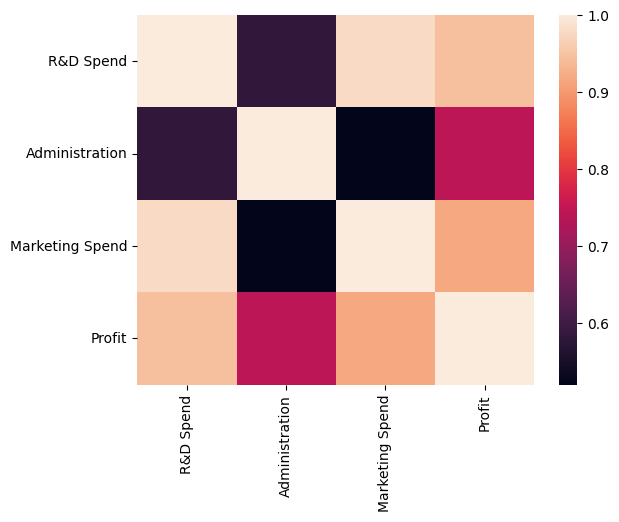

In [15]:
sns.heatmap(companies.drop('State', axis=1).corr())

In [17]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np

labelencoder = LabelEncoder()
X[:, 3] = labelencoder.fit_transform(X[:, 3])

# Instantiate OneHotEncoder without the deprecated 'categorical_features' argument
onehotencoder = OneHotEncoder()

# Fit and transform only the categorical column (X[:, 3]), reshaping it to a 2D array
X_state_onehot = onehotencoder.fit_transform(X[:, 3].reshape(-1, 1)).toarray()

# Concatenate the one-hot encoded 'State' columns with the rest of the features in X
X = np.concatenate((X[:, :3], X_state_onehot), axis=1)

In [18]:
X = X[:, 1:]

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [20]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [21]:
y_pred = regressor.predict(X_test)
y_pred

array([ 90565.4549183 ,  89231.66013825,  95558.1615789 , 173980.70753521,
        84392.40760654, 110960.02030434, 169853.27349786,  92211.50361802,
       163806.49460484,  54194.35845003,  68223.34420283, 149414.20662372,
       126880.09350258,  60777.09313745, 176374.873465  ,  76473.57865297,
       117801.00551913, 163717.67368519, 164505.66820024, 180897.36578723,
       101542.7710529 ,  86534.69207536, 179176.54723885,  85043.09150246,
       105448.72374492, 101758.7541275 ,  41156.33974605,  58440.90914855,
        70127.08647148, 227178.56810888, 120276.37402309, 112021.1671163 ,
       102074.21108737, 137081.85170533,  65308.13393229, 109216.7567128 ,
       184756.89248794, 169834.94778712, 172966.72131045, 117236.93367575,
        97421.45834874, 164576.37223589, 108107.91915771,  51232.14223946,
       116104.59322756,  60087.11249188, 157092.96939586,  78960.6347705 ,
       158375.5611409 , 130409.52059342, 182979.83473802, 172932.30629085,
        94434.21503434,  

In [22]:
print(regressor.coef_)

[ 1.04077565e+00  3.55369298e-01  6.92903025e+02 -7.69537277e+02
  7.66342524e+01]


In [23]:
print(regressor.intercept_)

-88812.35336549708


In [24]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.898228254958607